# Programming-language steering via attractor traversal

Companion to the paper's §*Attractors for traversals / language* (programming-language case). Build per-language mean-activation prototypes from Qwen-2.5-3B-Instruct on `greengerong/leetcode`, then inject one prototype into a middle attention layer during generation. The model, prompted to 're-state' a source program, transpiles it into the target language — the attractor steer.

## Setup

In [1]:
import os
import re
import copy

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from rich import print as pprint
from sklearn.manifold import TSNE
from openai import OpenAI
from datasets import load_dataset, Dataset
from transformers import AutoTokenizer, AutoModelForCausalLM


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

## Model

In [3]:
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-3B-Instruct")
model = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-3B-Instruct", torch_dtype=torch.bfloat16,
).to(device)
model = model.eval()


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/3.97G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

## Data

First run downloads `greengerong/leetcode` into `./leetcode_cache/`; subsequent runs load from that local cache.

In [4]:
ds = load_dataset("greengerong/leetcode", cache_dir="./leetcode_cache")['train']

README.md:   0%|          | 0.00/21.0 [00:00<?, ?B/s]

leetcode-train.jsonl:   0%|          | 0.00/16.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2360 [00:00<?, ? examples/s]

In [5]:
prompts = []
language = []

keep = 100

for l in ['java', 'c++', 'python', 'javascript']:
    for i in tqdm(range(min(keep, len(ds)))):
        prompts.append(ds[i][l].split('```')[1])
        language.append(l)

language = np.array(language)

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

## Prototype extraction

Hook every self-attention output, run one forward pass per prompt, mean-pool across the sequence, then group by language to form one mean-activation prototype per (language, layer).

In [6]:
activations = {}
def get_activation(name):
    def hook(model, input, output):
        if (name in activations):
            activations[name].append(output[0])
        else:
            activations[name] = [output[0]]
    return hook


hooks = []
for i, layer in enumerate(model.model.layers):
    hooks.append(layer.self_attn.register_forward_hook(get_activation(i)))

In [7]:
hidden_states = []

pbar = tqdm(enumerate(prompts), total=len(prompts))
for i, p in pbar:

    pbar.set_description('cur prompt length (chars): %d' %(len(p)))
    
    with torch.inference_mode():
        with torch.no_grad():
            inputs = tokenizer(p, return_tensors="pt").input_ids
            outputs = model.forward(inputs.to(device))
        
    for k in activations.keys():
        activations[k] = torch.cat(activations[k], dim=1).detach().cpu()
        activations[k] =  torch.mean(activations[k], dim=-2)


    hidden_states.append(copy.deepcopy(activations))
    activations = {}

  0%|          | 0/400 [00:00<?, ?it/s]

In [8]:
target_layers = list(range(len(model.model.layers)))
all_prompts_concepts = hidden_states

concepts = {l: {} for l in ['java', 'c++', 'python', 'javascript']}
for target_layer in target_layers:
    for l in ['java', 'c++', 'python', 'javascript']:
        cur_concepts = []
        for i in range(len(all_prompts_concepts)):
            if language[i] != l:
                continue
            cur_concepts.append(all_prompts_concepts[i][target_layer])
        cur_concepts = torch.stack(cur_concepts, dim=0)
        concepts[l][target_layer] = torch.mean(cur_concepts, dim=0)


## Prototype similarity

Pairwise cosine between every prompt's layer-19 activation. Prompts of the same language form clear diagonal blocks.

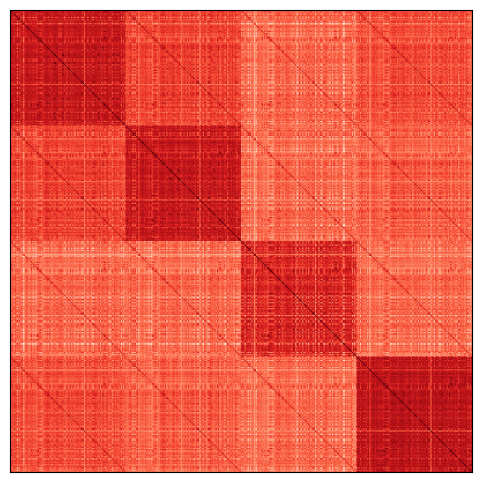

In [12]:
target_layer = 27

cs = np.zeros((len(prompts), len(prompts)))
cs_func = nn.CosineSimilarity(dim=-1)
for i in range(len(prompts)):
    for j in range(len(prompts)):
        cs[i, j] = cs_func(all_prompts_concepts[i][target_layer], all_prompts_concepts[j][target_layer])

fig, ax = plt.subplots(figsize=(6, 6))
plt.imshow(cs, cmap='Reds')
plt.xticks([]); plt.yticks([])
plt.show()


## Prototype t-SNE

At layer 24 the four languages separate cleanly in a 2-D t-SNE projection — the attractors the paper references.

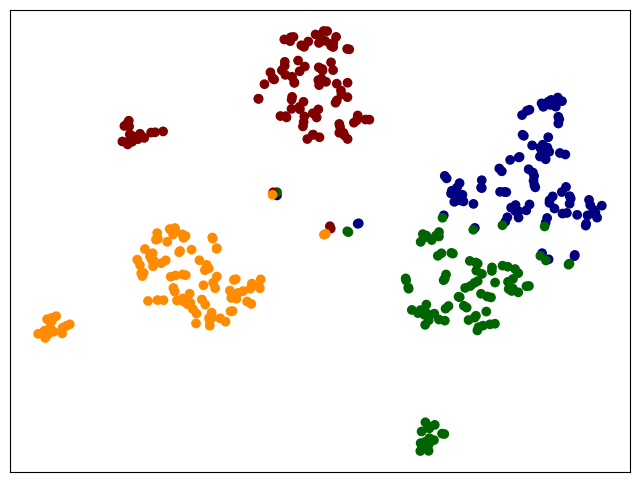

In [11]:
target_layer = 27

cur_concepts = []
for i in range(len(prompts)):
    cur_concepts.append(all_prompts_concepts[i][target_layer])
cur_concepts = torch.stack(cur_concepts, dim=0).squeeze()

cur_concepts_emb = TSNE(
    n_components=2, metric='cosine', learning_rate='auto',
    init='random', perplexity=8, random_state=0,
).fit_transform(cur_concepts.detach().cpu().float().numpy())

palette = {'python': 'maroon', 'c++': 'darkgreen', 'java': 'navy', 'javascript': 'darkorange'}
colors = [palette[language[i]] for i in range(cur_concepts_emb.shape[0])]

plt.figure(figsize=(8, 6))
plt.scatter(cur_concepts_emb[:, 0], cur_concepts_emb[:, 1], c=colors)
plt.xticks([]); plt.yticks([])
plt.show()


## Steering intervention

Remove the capture hooks and install one steering hook on layer 19 that adds `strength * concepts[target_language][target_layer]` to the attention output. `extract_program` strips the code fence from each generation.

In [13]:
for hook in hooks:
    hook.remove()

In [14]:
target_layer = 27
target_language = 'c++'
strength = 0  # overridden per-iteration in the sweep below


def change_behavior(target_layer):
    def hook(model, input, output):
        output = (output[0] + strength * concepts[target_language][target_layer].to(device), *output[1:])
        return output
    return hook


hook = model.model.layers[target_layer].self_attn.register_forward_hook(change_behavior(target_layer))


In [15]:
def extract_program(prompt, target_language, source_language):



    if (target_language == 'c++'):
        target_language = 'cpp' 

    splits = re.split(r'\b' + target_language, prompt)[1:]

    for i in range(len(splits)):
        splits[i] = re.split(r'```', splits[i])[0].strip()
    
    for i in range(len(splits)):
        if (len(splits[i]) > 30):
            return splits[i]
        

    splits = re.split(r'\b' + '%s|%s' %(target_language, source_language), prompt)[1:]

    for i in range(len(splits)):
        splits[i] = re.split(r'```', splits[i])[0].strip()
    
    for i in range(len(splits)):
        if (len(splits[i]) > 30):
            return splits[i]

    return ''


## Validation set

Hold out 100 leetcode examples past the first 100-per-language used to build the prototypes.

In [16]:
val_size = 100
np.random.seed(0)
val_idxs = np.random.choice(list(range(keep, len(ds))), size=val_size, replace=False)
val_ds = Dataset.from_dict(ds[val_idxs])


## Translation sweep

Loop over all 4×4 source/target language pairs but, for scope, only run `*→c++`. Appends per-direction prediction columns to `val_ds` and persists to `./programming_qwen.hf/`.

In [17]:
for source in ['java', 'c++', 'python', 'javascript']:
    for target in ['java', 'c++', 'python', 'javascript']:
        if source == target:
            continue
        if target != 'c++':
            # Faithful to the author's scope: only *->c++ is populated.
            continue

        target_language = target
        strength = 6

        preds = []
        for val_idx in tqdm(range(len(val_ds)), desc=f'{source}->{target}'):
            prompt = (
                "Re-state the following program. "
                "Do not include an explanation.\n\n"
                f"```{val_ds[val_idx][source]}```"
            )
            with torch.inference_mode(), torch.no_grad():
                inputs = tokenizer(prompt, return_tensors="pt").input_ids
                outputs = model.generate(
                    inputs.to(device),
                    max_new_tokens=int(inputs.shape[1] * 1.8),
                    do_sample=False, top_k=20, top_p=0.95,
                    pad_token_id=tokenizer.eos_token_id, use_cache=True,
                ).detach().cpu()
                output_text = tokenizer.batch_decode(outputs[:, inputs.shape[1]:], skip_special_tokens=True)[0]
            preds.append(extract_program(output_text, target_language, source))

        val_ds = val_ds.add_column(f'{source}->{target}', preds)

val_ds.save_to_disk('programming_qwen.hf')


java->c++:   0%|          | 0/100 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


python->c++:   0%|          | 0/100 [00:00<?, ?it/s]

KeyboardInterrupt: 

## GPT-4.1-nano evaluation

Rate every `javascript→c++` translation 1-5 with gpt-4.1-nano and print the mean / std. Requires an OpenAI API key at `../openai_token.txt` (i.e. `traversals/openai_token.txt`).

In [ ]:
with open('../openai_token.txt', 'r') as f:
    openai_api_key = f.readline().strip()

client = OpenAI(api_key=openai_api_key)

source = 'javascript'
target = 'c++'

scores = []
for i in tqdm(range(len(val_ds))):
    prompt = (
        "Rate the translation of the original program from 1 to 5. "
        "Do not reduce score for name changes."
        "Give your response in the format '{score}/5. {Reason}'."
    )
    prompt += "-" * 60
    prompt += f"\nORIGINAL: {val_ds[i][target]}\n"
    prompt += "-" * 60
    prompt += f"\nTRANSLATION: {val_ds[i][f'{source}->{target}']}"

    response = client.chat.completions.create(
        model="gpt-4.1-nano",
        messages=[
            {"role": "system", "content": "You are a helpful assistant."},
            {"role": "user", "content": prompt},
        ],
        max_tokens=20,
        temperature=0.0,
    )
    scores.append(response.choices[0].message.content)

number_scores = []
for s in scores:
    try:
        number_scores.append(int(s[0]))
    except (ValueError, IndexError):
        number_scores.append(1)

print(f'mean: {np.mean(number_scores):.2f}, std: {np.std(number_scores):.2f}')
